# Danish Housing Price Forecasting
## Notebook 1: Exploratory Data Analysis

**Goal:** Understand each dataset — structure, time coverage, missing values, distributions, and relationships.

**Datasets:**
- `housing_prices.csv` — EJ121: quarterly price index, seasonally adjusted
- `interest_rates.csv` — DNRNURI: monthly mortgage rates
- `unemployment.csv` — AUP01: unemployment rate
- `population.csv` — FOLK1A: quarterly population

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

plt.rcParams['figure.figsize'] = (12, 4)

RAW = 'data/raw/'

---
## 1. Housing Prices (EJ121)

In [ ]:
prices = pd.read_csv('../'+RAW + 'housing_prices.csv', sep=None, engine='python')
#Examine format
print('Shape:', prices.shape)
print('\nColumns:', prices.columns.tolist())
print('\nFirst rows:')
prices.head(10)

Shape: (170, 5)

Columns: ['REGION', 'EJKAT20', 'TAL', 'TID', 'INDHOLD']

First rows:


,REGION,EJKAT20,TAL,TID,INDHOLD
0,All Denmark,One-family houses,"Priceindex, seasonally adjusted",2007Q2,81.1
1,All Denmark,"Owner-occupied flats, total","Priceindex, seasonally adjusted",2007Q2,67.2
2,All Denmark,One-family houses,"Priceindex, seasonally adjusted",2008Q4,72.3
3,All Denmark,"Owner-occupied flats, total","Priceindex, seasonally adjusted",2008Q4,57.0
4,All Denmark,One-family houses,"Priceindex, seasonally adjusted",2009Q1,68.3
5,All Denmark,"Owner-occupied flats, total","Priceindex, seasonally adjusted",2009Q1,52.0
6,All Denmark,One-family houses,"Priceindex, seasonally adjusted",2009Q2,67.2
7,All Denmark,"Owner-occupied flats, total","Priceindex, seasonally adjusted",2009Q2,52.3
8,All Denmark,One-family houses,"Priceindex, seasonally adjusted",2010Q1,69.0
9,All Denmark,"Owner-occupied flats, total","Priceindex, seasonally adjusted",2010Q1,54.6


In [ ]:
# Examine data types, missing values, and unique values per column
print('Data types:')
print(prices.dtypes)
print('\nMissing values:')
print(prices.isnull().sum())
print('\nUnique values per column:')
for col in prices.columns:
    print(f'  {col}: {prices[col].nunique()} unique values')
    if prices[col].nunique() < 10:
        print(f'    {prices[col].unique()}')

Data types:
REGION         str
EJKAT20        str
TAL            str
TID            str
INDHOLD    float64
dtype: object

Missing values:
REGION     0
EJKAT20    0
TAL        0
TID        0
INDHOLD    0
dtype: int64

Unique values per column:
  REGION: 1 unique values
    <StringArray>
['All Denmark']
Length: 1, dtype: str
  EJKAT20: 2 unique values
    <StringArray>
['One-family houses', 'Owner-occupied flats, total']
Length: 2, dtype: str
  TAL: 1 unique values
    <StringArray>
['Priceindex, seasonally adjusted']
Length: 1, dtype: str
  TID: 85 unique values
  INDHOLD: 146 unique values


In [ ]:
# Parse the time column (format: 2005Q1)
# We need to identify the time column name first
time_col = [c for c in prices.columns if 'TID'][0]
value_col = [c for c in prices.columns if c != time_col][0]
print(f'Time column: {time_col}')
print(f'Value column: {value_col}')
print(f'\nTime range: {prices[time_col].min()} to {prices[time_col].max()}')

Time column: REGION
Value column: INDHOLD

Time range: All Denmark to All Denmark


In [9]:
# Time is already in standard format '2007Q2' — parse directly
prices['date'] = pd.PeriodIndex(prices['TID'], freq='Q').to_timestamp()

# Pivot: one column per property category
prices_wide = prices.pivot_table(index='date', columns='EJKAT20', values='INDHOLD')
prices_wide.columns.name = None
print('Shape:', prices_wide.shape)
print('Date range:', prices_wide.index.min(), 'to', prices_wide.index.max())
prices_wide.head()

Shape: (85, 2)
Date range: 2005-01-01 00:00:00 to 2026-01-01 00:00:00


,One-family houses,"Owner-occupied flats, total"
date,,
2005-01-01,58.5,50.6
2005-04-01,61.1,53.7
2005-07-01,64.8,57.8
2005-10-01,69.6,62.6
2006-01-01,74.1,66.9


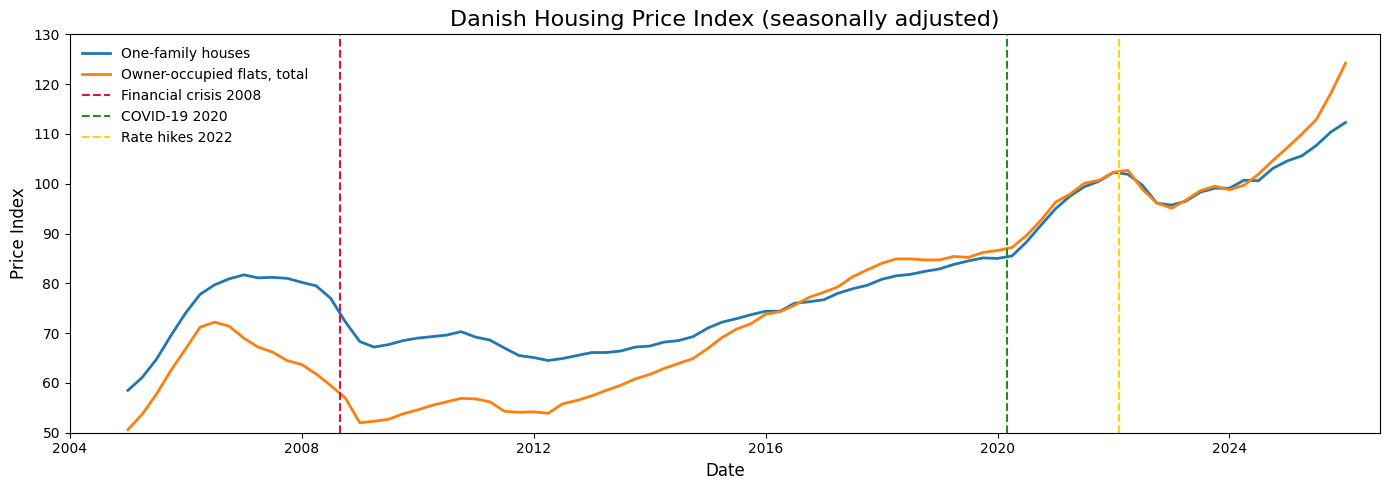

Key observations:
- Peak before 2008 financial crisis
- Long recovery 2012-2020
- Sharp rise during COVID (low rates, demand surge)
- Correction after 2022 rate hikes


In [20]:
fig, ax = plt.subplots(figsize=(14, 5))
for col in prices_wide.columns:
    ax.plot(prices_wide.index, prices_wide[col], label=str(col), linewidth=2)

# Mark key events
ax.axvline(pd.Timestamp('2008-09-01'), color='crimson', linestyle='--',  label='Financial crisis 2008')
ax.axvline(pd.Timestamp('2020-03-01'), color='forestgreen', linestyle='--',  label='COVID-19 2020')
ax.axvline(pd.Timestamp('2022-02-01'), color='gold', linestyle='--', label='Rate hikes 2022')

ax.set_title('Danish Housing Price Index (seasonally adjusted)', fontsize=16)
ax.set_xlabel('Date', fontsize=12)
ax.set_ylabel('Price Index',fontsize=12)
ax.set_xlim(pd.Timestamp('2004-01-01'), pd.Timestamp('2026-08-06'))
ax.set_ylim(50,130)
ax.legend(frameon =False, fontsize =10)
ax.grid(False)
plt.tight_layout()
plt.savefig('../data/processed/plot_prices.png', dpi=150)
plt.show()
print('Key observations:')
print('- Peak before 2008 financial crisis')
print('- Long recovery 2012-2020')
print('- Sharp rise during COVID (low rates, demand surge)')
print('- Correction after 2022 rate hikes')

---
## 2. Interest Rates (DNRNURI)

In [23]:
rates = pd.read_csv('../' + RAW + 'interest_rates.csv', sep=None, engine='python')
print('Shape:', rates.shape)
print('\nColumns:', rates.columns.tolist())
rates.head()

Shape: (282, 8)

Columns: ['DATA', 'INDSEK', 'VALUTA', 'LØBETID1', 'RENTFIX', 'LAANSTR', 'TID', 'INDHOLD']


,DATA,INDSEK,VALUTA,LØBETID1,RENTFIX,LAANSTR,TID,INDHOLD
0,Annualised agreed rate incl. administration ra...,- 1430: Households - employees etc.,- of which DKK,All maturities,All interest rate fixation periods,Alle sizes of loans,2003M01,..
1,Annualised agreed rate incl. administration ra...,- 1430: Households - employees etc.,- of which DKK,All maturities,All interest rate fixation periods,Alle sizes of loans,2003M02,..
2,Annualised agreed rate incl. administration ra...,- 1430: Households - employees etc.,- of which DKK,All maturities,All interest rate fixation periods,Alle sizes of loans,2003M03,..
3,Annualised agreed rate incl. administration ra...,- 1430: Households - employees etc.,- of which DKK,All maturities,All interest rate fixation periods,Alle sizes of loans,2003M04,..
4,Annualised agreed rate incl. administration ra...,- 1430: Households - employees etc.,- of which DKK,All maturities,All interest rate fixation periods,Alle sizes of loans,2003M05,..


In [24]:
print('Unique values per column:')
for col in rates.columns:
    n = rates[col].nunique()
    print(f'  {col}: {n} unique')
    if n < 8:
        print(f'    {rates[col].unique()}')

Unique values per column:
  DATA: 1 unique
    <StringArray>
['Annualised agreed rate incl. administration rate (per cent) (not indexed)']
Length: 1, dtype: str
  INDSEK: 1 unique
    <StringArray>
[' - 1430: Households - employees etc. ']
Length: 1, dtype: str
  VALUTA: 1 unique
    <StringArray>
['- of which DKK']
Length: 1, dtype: str
  LØBETID1: 1 unique
    <StringArray>
['All maturities']
Length: 1, dtype: str
  RENTFIX: 1 unique
    <StringArray>
['All interest rate fixation periods']
Length: 1, dtype: str
  LAANSTR: 1 unique
    <StringArray>
['Alle sizes of loans']
Length: 1, dtype: str
  TID: 282 unique
  INDHOLD: 148 unique


In [30]:
# Clean interest rates
# 1. Remove non-data rows where TID is not a date (e.g. 'All maturities')
rates = rates[rates['TID'].str.match(r'^\d{4}M\d{2}$', na=False)].copy()

# 2. Replace '..' with NaN and convert INDHOLD to float
rates['INDHOLD'] = pd.to_numeric(rates['INDHOLD'].replace('..', np.nan), errors='coerce')

# 3. Drop rows with NaN values
rates = rates.dropna(subset=['INDHOLD'])

print('Cleaned shape:', rates.shape)
print('Missing values:', rates['INDHOLD'].isnull().sum())
print('Sample:')
rates.head()

Cleaned shape: (153, 8)
Missing values: 0
Sample:


,DATA,INDSEK,VALUTA,LØBETID1,RENTFIX,LAANSTR,TID,INDHOLD
129,Annualised agreed rate incl. administration ra...,- 1430: Households - employees etc.,- of which DKK,All maturities,All interest rate fixation periods,Alle sizes of loans,2013M10,2.899
130,Annualised agreed rate incl. administration ra...,- 1430: Households - employees etc.,- of which DKK,All maturities,All interest rate fixation periods,Alle sizes of loans,2013M11,2.647
131,Annualised agreed rate incl. administration ra...,- 1430: Households - employees etc.,- of which DKK,All maturities,All interest rate fixation periods,Alle sizes of loans,2013M12,2.290
132,Annualised agreed rate incl. administration ra...,- 1430: Households - employees etc.,- of which DKK,All maturities,All interest rate fixation periods,Alle sizes of loans,2014M01,2.208
133,Annualised agreed rate incl. administration ra...,- 1430: Households - employees etc.,- of which DKK,All maturities,All interest rate fixation periods,Alle sizes of loans,2014M02,2.516


In [35]:
# Monthly data — parse and resample to quarterly
time_col_r = [c for c in rates.columns if 'tid' in c.lower() or 'time' in c.lower()][-1]
value_col_r = [c for c in rates.columns if rates[c].dtype in ['float64', 'int64']][-1]

print(f'Time column: {time_col_r}, Value column: {value_col_r}')

# Parse monthly format e.g. '2003M01'
rates['date'] = pd.to_datetime(rates[time_col_r].astype(str).str.replace('M', '-'), format='%Y-%m')

# Keep only the rows we need (all maturities, all fixation, DKK, households employees)
# Filter based on what columns exist
rates_clean = rates.copy()
rates_clean = rates_clean.dropna(subset=[value_col_r])

# Resample to quarterly mean
rates_q = rates_clean.groupby('date')[value_col_r].mean().resample('QS').mean()
print('\nQuarterly rates shape:', rates_q.shape)
rates_q.tail()

Time column: TID, Value column: INDHOLD

Quarterly rates shape: (51,)


date
2025-04-01    3.852000
2025-07-01    3.668000
2025-10-01    3.591667
2026-01-01    3.801000
2026-04-01    3.931667
Freq: QS-JAN, Name: INDHOLD, dtype: float64

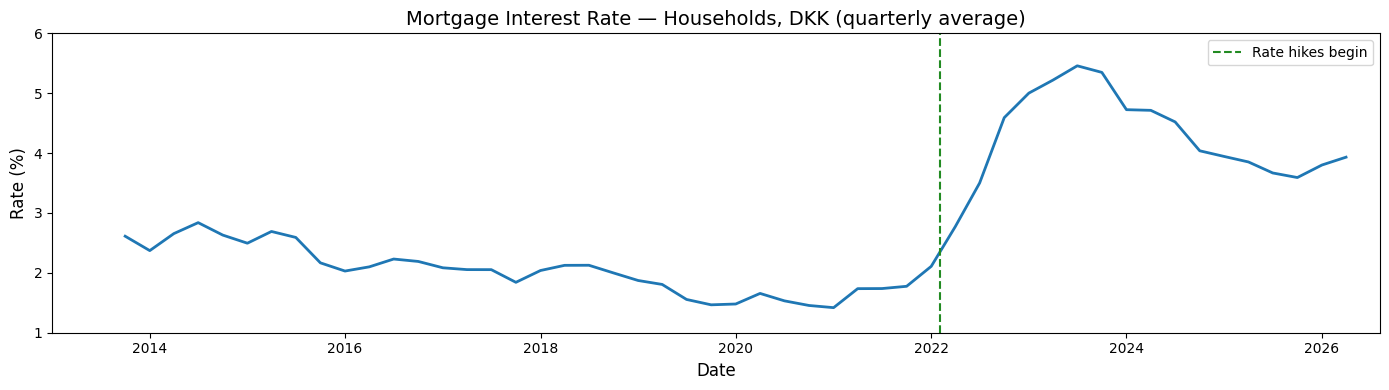

In [39]:
fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(rates_q.index, rates_q.values, linewidth=2)
ax.axvline(pd.Timestamp('2022-02-01'), color='forestgreen', linestyle='--', label='Rate hikes begin')
ax.set_title('Mortgage Interest Rate — Households, DKK (quarterly average)', fontsize=14)
ax.set_xlabel('Date',fontsize=12)
ax.set_ylabel('Rate (%)', fontsize=12)
ax.set_xlim(pd.Timestamp('2013-01-01'), pd.Timestamp('2026-08-06'))
ax.set_ylim(1,6)
ax.legend(frameon =False, fontsize =10)
ax.grid(False)
ax.legend()
plt.tight_layout()
plt.savefig('../data/processed/plot_rates.png', dpi=150)
plt.show()

---
## 3. Unemployment (AUP01)

In [40]:
unemp = pd.read_csv('../'+ RAW + 'unemployment.csv', sep=None, engine='python')
print('Shape:', unemp.shape)
print('Columns:', unemp.columns.tolist())
print('\nMissing:', unemp.isnull().sum().to_dict())
unemp.head(10)

Shape: (108, 5)
Columns: ['OMRÅDE', 'ALDER', 'KØN', 'TID', 'INDHOLD']

Missing: {'OMRÅDE': 0, 'ALDER': 0, 'KØN': 0, 'TID': 0, 'INDHOLD': 0}


,OMRÅDE,ALDER,KØN,TID,INDHOLD
0,All Denmark,"Age, total",Total,2017M07,4.0
1,All Denmark,"Age, total",Total,2017M08,4.1
2,All Denmark,"Age, total",Total,2017M09,3.9
3,All Denmark,"Age, total",Total,2017M10,4.0
4,All Denmark,"Age, total",Total,2017M11,4.0
5,All Denmark,"Age, total",Total,2017M12,4.1
6,All Denmark,"Age, total",Total,2018M01,4.2
7,All Denmark,"Age, total",Total,2018M02,4.2
8,All Denmark,"Age, total",Total,2018M03,4.1
9,All Denmark,"Age, total",Total,2018M04,3.7


In [41]:
print('Unique values per column:')
for col in unemp.columns:
    n = unemp[col].nunique()
    print(f'  {col}: {n} unique')
    if n < 10:
        print(f'    {unemp[col].unique()}')

Unique values per column:
  OMRÅDE: 1 unique
    <StringArray>
['All Denmark']
Length: 1, dtype: str
  ALDER: 1 unique
    <StringArray>
['Age, total']
Length: 1, dtype: str
  KØN: 1 unique
    <StringArray>
['Total']
Length: 1, dtype: str
  TID: 108 unique
  INDHOLD: 28 unique


In [42]:
# Parse time — could be monthly or quarterly
time_col_u = [c for c in unemp.columns if 'tid' in c.lower() or 'time' in c.lower()][0]
value_col_u = [c for c in unemp.columns if unemp[c].dtype in ['float64', 'int64']][-1]
print(f'Time: {time_col_u}, Value: {value_col_u}')
print('Sample times:', unemp[time_col_u].head(5).tolist())

# Detect format and parse
sample = str(unemp[time_col_u].iloc[0])
if 'M' in sample:
    unemp['date'] = pd.to_datetime(unemp[time_col_u].astype(str).str.replace('M', '-'), format='%Y-%m')
    unemp_q = unemp.groupby('date')[value_col_u].mean().resample('QS').mean()
elif 'K' in sample:
    unemp['period'] = unemp[time_col_u].apply(parse_dst_quarter)
    unemp['date'] = unemp['period'].dt.to_timestamp()
    unemp_q = unemp.set_index('date')[value_col_u]
else:
    print('Unknown time format — inspect manually')
    unemp_q = None

if unemp_q is not None:
    print('\nQuarterly unemployment shape:', unemp_q.shape)
    unemp_q.tail()

Time: TID, Value: INDHOLD
Sample times: ['2017M07', '2017M08', '2017M09', '2017M10', '2017M11']

Quarterly unemployment shape: (36,)


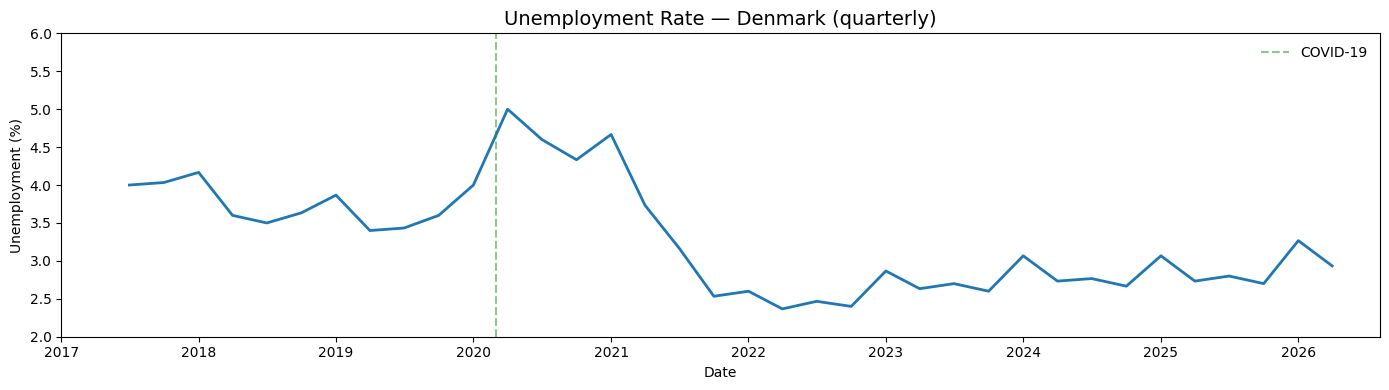

In [45]:
if unemp_q is not None:
    fig, ax = plt.subplots(figsize=(14, 4))
    ax.plot(unemp_q.index, unemp_q.values, linewidth=2)
    #ax.axvline(pd.Timestamp('2008-09-01'), color='red', linestyle='--', alpha=0.5, label='Financial crisis')
    ax.axvline(pd.Timestamp('2020-03-01'), color='forestgreen', linestyle='--', alpha=0.5, label='COVID-19')
    ax.set_title('Unemployment Rate — Denmark (quarterly)', fontsize=14)
    ax.set_xlabel('Date')
    ax.set_ylabel('Unemployment (%)')
    ax.set_xlim(pd.Timestamp('2017-01-01'), pd.Timestamp('2026-08-06'))
    ax.set_ylim(2,6)
    ax.legend(frameon =False, fontsize =10)
    ax.grid(False)
    plt.tight_layout()
    plt.savefig('../data/processed/plot_unemployment.png', dpi=150)
    plt.show()

---
## 4. Population (FOLK1A)

In [54]:
pop = pd.read_csv('../'+RAW + 'population.csv', sep=None, engine='python')
print('Shape:', pop.shape)
print('Columns:', pop.columns.tolist())
pop.head()

Shape: (222, 6)
Columns: ['OMRÅDE', 'KØN', 'ALDER', 'CIVILSTAND', 'TID', 'INDHOLD']


,OMRÅDE,KØN,ALDER,CIVILSTAND,TID,INDHOLD
0,All Denmark,Men,"Age, total",Total,2008Q1,2712666
1,All Denmark,Women,"Age, total",Total,2008Q1,2763125
2,All Denmark,Total,"Age, total",Total,2008Q1,5475791
3,All Denmark,Men,"Age, total",Total,2008Q2,2716310
4,All Denmark,Women,"Age, total",Total,2008Q2,2765956


In [55]:
pop = pop[pop['KØN'].str.match('Total', na=False)].copy()

In [ ]:
time_col_p = [c for c in pop.columns if 'tid' in c.lower() or 'time' in c.lower()][0]
value_col_p = [c for c in pop.columns if pop[c].dtype in ['float64', 'int64']][-1]
print(f'Time: {time_col_p}, Value: {value_col_p}')

sample_p = str(pop[time_col_p].iloc[0])
if 'K' in sample_p:
    pop['period'] = pop[time_col_p].apply(parse_dst_quarter)
    pop['date'] = pop['period'].dt.to_timestamp()
elif 'Q' in sample_p:
    pop['date'] = pd.PeriodIndex(pop[time_col_p], freq='Q').to_timestamp()
else:
    pop['date'] = pd.to_datetime(pop[time_col_p])

pop_q = pop.set_index('date')[value_col_p].sort_index()
print('Shape:', pop_q.shape)
pop_q.tail()

Time: TID, Value: INDHOLD
Shape: (74,)


date
2025-04-01    5999677
2025-07-01    6002420
2025-10-01    6019866
2026-01-01    6025603
2026-04-01    6031247
Name: INDHOLD, dtype: int64

C:\Users\pwb939\AppData\Local\Temp\ipykernel_13300\915325909.py:8: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(frameon =False, fontsize =10)


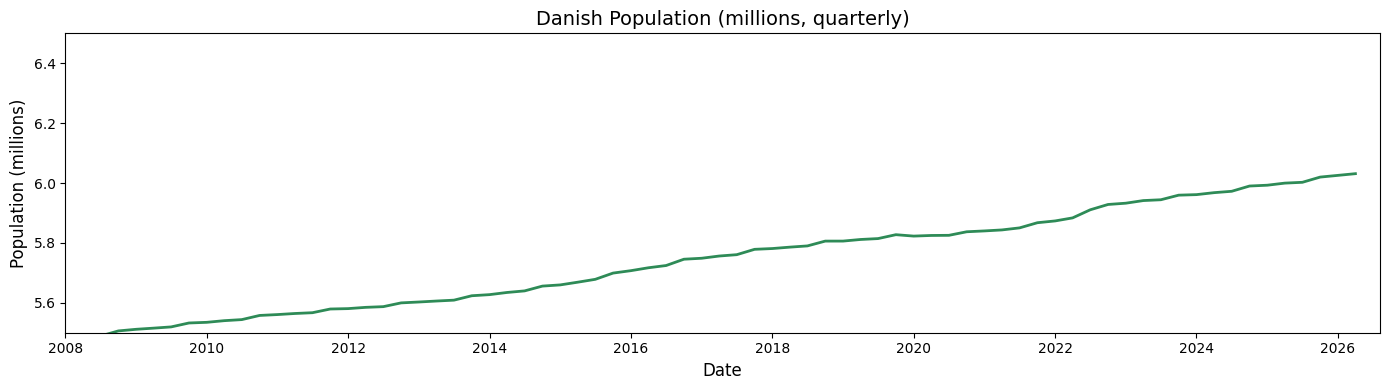

In [58]:
fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(pop_q.index, pop_q.values / 1e6, color='seagreen', linewidth=2)
ax.set_title('Danish Population (millions, quarterly)', fontsize=14)
ax.set_xlabel('Date', fontsize=12)
ax.set_ylabel('Population (millions)', fontsize=12)
ax.set_xlim(pd.Timestamp('2008-01-01'), pd.Timestamp('2026-08-06'))
ax.set_ylim(5.5,6.5)
ax.legend(frameon =False, fontsize =10)
ax.grid(False)
plt.tight_layout()
plt.savefig('../data/processed/plot_population.png', dpi=150)
plt.show()

---
## 6. Correlation overview

Align all series on quarterly dates and look at pairwise correlations with housing prices.

In [124]:
# Use one-family houses price index as our target
# Select the first column of prices_wide (one-family houses)
target = prices_wide.iloc[:, 0].rename('house_price_index')
target.index = pd.DatetimeIndex(target.index)

# Build combined dataframe
df_all = pd.DataFrame({
    'house_price_index': target,
})

# Add other series if they exist
try:
    df_all['interest_rate'] = rates_q
except:
    print('Interest rates not available')
try:
    df_all['unemployment'] = unemp_q
except:
    print('Unemployment not available')
try:
    df_all['population'] = pop_q
except:
    print('Population not available')


df_all = df_all.dropna()
print('Combined dataset shape:', df_all.shape)
print('Date range:', df_all.index.min(), 'to', df_all.index.max())
df_all.head()

Combined dataset shape: (35, 4)
Date range: 2017-07-01 00:00:00 to 2026-01-01 00:00:00


,house_price_index,interest_rate,unemployment,population
date,,,,
2017-07-01,78.9,2.053333,4.000000,5760694.0
2017-10-01,79.6,1.841667,4.033333,5778570.0
2018-01-01,80.8,2.039000,4.166667,5781190.0
2018-04-01,81.5,2.125333,3.600000,5785864.0
2018-07-01,81.8,2.126667,3.500000,5789957.0


In [126]:
print('(Pearson) Correlation with house_price_index:')
print(df_all.corr()['house_price_index'].sort_values(ascending=False))

(Pearson) Correlation with house_price_index:
house_price_index    1.000000
population           0.904853
interest_rate        0.588481
unemployment        -0.659831
Name: house_price_index, dtype: float64


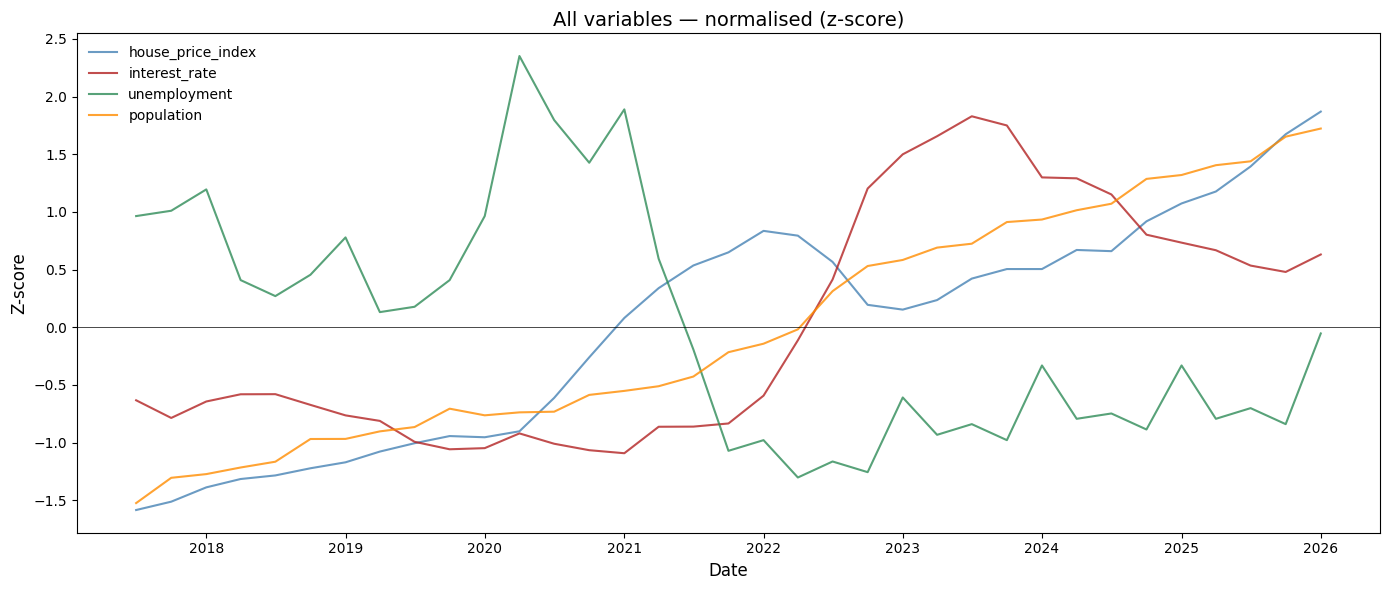

In [128]:
# Plot all series normalised (z-score) on same axis
df_norm = (df_all - df_all.mean()) / df_all.std()

fig, ax = plt.subplots(figsize=(14, 6))
colors = ['steelblue', 'firebrick', 'seagreen', 'darkorange', 'purple']
for col, color in zip(df_norm.columns, colors):
    ax.plot(df_norm.index, df_norm[col], label=col, linewidth=1.5, alpha=0.8, color=color)

ax.axhline(0, color='black', linewidth=0.5)
ax.set_title('All variables — normalised (z-score)', fontsize=14)
ax.set_xlabel('Date',fontsize=12)
ax.set_ylabel('Z-score', fontsize=12)
ax.legend(frameon=False, fontsize=10)
ax.grid(False)
plt.tight_layout()
plt.savefig('../data/processed/plot_all_normalised.png', dpi=150)
plt.show()

In [129]:
# Save combined dataset for use in next notebook
import os
os.makedirs('../data/processed', exist_ok=True)
df_all.to_csv('../data/processed/combined_raw.csv', index=False)
print('Saved ../data/processed/combined_raw.csv')
print('\nSummary statistics:')
df_all.describe()

Saved ../data/processed/combined_raw.csv

Summary statistics:


,house_price_index,interest_rate,unemployment,population
count,35.000000,35.000000,35.000000,3.500000e+01
mean,94.225714,2.929390,3.305714,5.885092e+06
std,9.667177,1.382366,0.720543,8.156572e+04
min,78.900000,1.418667,2.366667,5.760694e+06
25%,84.750000,1.756500,2.700000,5.818612e+06
50%,96.500000,2.125333,3.166667,5.867412e+06
75%,100.650000,3.990667,3.800000,5.960356e+06
max,112.300000,5.457667,5.000000,6.025603e+06


---
## 7. Summary

- Data range covers from 2017 to 2026
- There does not seam to be any clear outlier or data quality issue
- Population seams to be higly correlated with price indices (this is likely spurious correlation driven by the shared trend, not a causal relationship)
- There clear changes in trend related to COVID and 2022
- The price series is clearly non stationary

Correlations in levels are likely spurious due to shared trends. All variables will be differenced before modelling to ensure stationarity. We expect the interest rate correlation to flip negative after differencing